<a href="https://colab.research.google.com/github/gabriela-abi/data-science-analytics-puc-rio/blob/main/MVP_An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Gabriela Oliveira Abi Chahin de Lima Gonçalves

**Matrícula:** 4052026000076

**Dataset:** [The Movie Database](https://www.kaggle.com/datasets/rishabhkumar2003/the-movie-database-tmdb-comprehensive-dataset)

# Descrição do Problema

O The Movie Database (TMDb) é um conjunto de dados com informações detalhadas sobre aproximadamente 10.000 filmes, incluindo metadados sobre produções, elenco, equipe técnica, gêneros e avaliações de usuários. O objetivo do dataset é possibilitar análises sobre desempenho financeiro dos filmes.

O conjunto completo é composto por cinco tabelas: movies, cast, crew, genres e reviews. A tabela movies reúne os principais metadados dos filmes, como título, data de lançamento, orçamento, receita e avaliações.

Para o MVP deste projeto, será utilizada apenas a tabela movies, permitindo análises relacionadas às características dos filmes e à distribuição e desempenho das produções.

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. **Filmes com maior orçamento tendem a apresentar maior faturamento?**

2. **O mês de lançamento de um filme influencia seu faturamento?**

3. **Filmes com maior orçamento apresentam maior retorno sobre investimento (ROI)?**

## Tipo de Problema

Este é um problema de **aprendizado supervisionado**. Dado um conjunto de características dos filmes (como orçamento, faturamento e data de lançamento), o objetivo é prever uma variável de interesse relacionada ao desempenho financeiro do filme.

## Seleção de Dados

O dataset utilizado neste projeto tem como base dados do The Movie Database (TMDb), uma plataforma online colaborativa criada em 2008 que reúne informações detalhadas sobre filmes, séries, elenco e profissionais da indústria audiovisual. A disponibilidade pública dos dados, aliada à riqueza de atributos disponíveis, torna esse dataset adequado para a realização de análises exploratórias e para o desenvolvimento futuro de modelos de machine learning voltados à análise do desempenho de filmes.

## Atributos do Dataset

O dataset MOVIES.CSV contém informações de aproximadamente 9.770 filmes obtidas do The Movie Database (TMDB). Cada linha representa um filme com dados sobre produção, lançamento e popularidade. Possui 22 atributos:

* id (identificador único do filme no TMDB)

* title (título do filme em inglês)

* original_title (título original no idioma nativo)

* overview (sinopse ou descrição do filme)

* release_date (data de lançamento)

* runtime (duração em minutos)

* budget (orçamento de produção em USD)

* revenue (receita de bilheteria em USD)

* vote_average (média das avaliações dos usuários, 0–10)

* vote_count (número total de avaliações)

* popularity (pontuação de popularidade no TMDB)

* poster_path (caminho da imagem do pôster)

* backdrop_path (caminho da imagem de fundo)

* status (status de lançamento do filme)

* tagline (frase de divulgação do filme)

* homepage (site oficial do filme)

* original_language (código do idioma original)

* adult (indicador de conteúdo adulto: 0 ou 1)

* video (indicador se é vídeo: 0 ou 1)

* created_at (data de criação do registro)

* updated_at (data da última atualização)

* genres (lista de gêneros do filme)

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset movies.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import FuncFormatter, MultipleLocator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [75]:
# carregamento do dataset
df_movies = pd.read_csv('https://raw.githubusercontent.com/gabriela-abi/data-science-analytics-puc-rio/refs/heads/main/movies.csv', sep=',', engine='python')

In [76]:
# primeiras linhas
df_movies.head()

,id,title,original_title,overview,release_date,runtime,budget,revenue,vote_average,vote_count,...,backdrop_path,status,tagline,homepage,original_language,adult,video,created_at,updated_at,genres
0,2,Ariel,Ariel,A Finnish man goes to the city to find a job a...,1988-10-21,73.0,0.0,0.0,7.102,368,...,/hQ4pYsIbP22TMXOUdSfC2mjWrO0.jpg,Released,NaN,NaN,fi,0,0,2026-02-13 12:09:05,2026-02-13T17:39:05.734678,"Drama,Comedy,Crime,Romance"
1,11,Star Wars,Star Wars,Princess Leia is captured and held hostage by ...,1977-05-25,121.0,11000000.0,775398007.0,8.202,21922,...,/2w4xG178RpB4MDAIfTkqAuSJzec.jpg,Released,"A long time ago in a galaxy far, far away...",http://www.starwars.com/films/star-wars-episod...,en,0,0,2026-02-13 10:49:07,2026-02-13T16:19:07.277805,"Adventure,Action,Science Fiction"
2,12,Finding Nemo,Finding Nemo,"Nemo, an adventurous young clownfish, is unexp...",2003-05-30,100.0,94000000.0,940335536.0,7.817,20256,...,/eCynaAOgYYiw5yN5lBwz3IxqvaW.jpg,Released,There are 3.7 trillion fish in the ocean. They...,http://movies.disney.com/finding-nemo,en,0,0,2026-02-13 10:52:41,2026-02-13T16:22:41.330322,"Animation,Family"
3,13,Forrest Gump,Forrest Gump,A man with a low IQ has accomplished great thi...,1994-06-23,142.0,55000000.0,677387716.0,8.462,29226,...,/67HggiWaP9ZLv5sPYmyRV37yAJM.jpg,Released,The world will never be the same once you've s...,https://www.paramountmovies.com/movies/forrest...,en,0,0,2026-02-13 10:49:10,2026-02-13T16:19:10.070631,"Drama,Comedy,Romance"
4,14,American Beauty,American Beauty,"Lester Burnham, a depressed suburban father in...",1999-09-15,122.0,15000000.0,356296601.0,8.002,12792,...,/2ndw55F40IkALzWyjCCza3M6nqM.jpg,Released,... look closer,NaN,en,0,0,2026-02-13 11:14:17,2026-02-13T16:44:17.072753,Drama


# Análise de Dados

A análise exploratória de dados (EDA) buscará verificar se variáveis como orçamento, lucro e data de lançamento apresentam relação com o desempenho financeiro dos filmes. Caso tais relações sejam confirmadas, essas variáveis poderão ser utilizadas futuramente na construção de um modelo de machine learning capaz de prever o faturamento de produções cinematográficas.

## Total e Tipo das Instâncias

In [19]:
print(f"Total de instâncias: {len(df_movies)}")
print("\nTipos de dados por coluna:")
print(df_movies.info())

Total de instâncias: 9771

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9771 entries, 0 to 9770
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 9771 non-null   object 
 1   title              9771 non-null   object 
 2   original_title     9771 non-null   object 
 3   overview           9611 non-null   object 
 4   release_date       9710 non-null   object 
 5   runtime            9770 non-null   float64
 6   budget             9770 non-null   float64
 7   revenue            9770 non-null   float64
 8   vote_average       9770 non-null   object 
 9   vote_count         9770 non-null   object 
 10  popularity         9770 non-null   object 
 11  poster_path        9433 non-null   object 
 12  backdrop_path      8252 non-null   object 
 13  status             9770 non-null   object 
 14  tagline            5968 non-null   object 
 15  homepage          

## Tratamento de nulos e filtros

Para a análise dos dados, trabalharemos apenas com filmes lançados entre 2000 e 2025 e com valores para budget e revenue não nulos ou 0.

In [20]:
# 1. Cópia e Conversão Inicial
df_elegivel = df_movies.copy()

# Tratamento de dados numéricos (garantindo que strings inválidas virem NaN)
df_elegivel['budget'] = pd.to_numeric(df_elegivel['budget'], errors='coerce')
df_elegivel['revenue'] = pd.to_numeric(df_elegivel['revenue'], errors='coerce')

# 2. Tratamento de Datas (Antes da filtragem para evitar erros)
df_elegivel['release_date'] = pd.to_datetime(df_elegivel['release_date'], errors='coerce')

# 3. Definição de Elegibilidade (Máscara Booleana)
mask = (
    (df_elegivel['revenue'] > 0) &
    (df_elegivel['budget'] > 0) &
    (df_elegivel['release_date'].notna())
)

# Aplicando o filtro principal
df_filtered = df_elegivel[mask].copy()

# 4. Criação de Colunas Temporais e Financeiras
df_filtered['year'] = df_filtered['release_date'].dt.year
df_filtered['month'] = df_filtered['release_date'].dt.month

# Aplicando o filtro de período (2000-2025) sem destruir o DataFrame
df_filtered = df_filtered[(df_filtered['year'] >= 2000) & (df_filtered['year'] <= 2025)]

# Cálculos financeiros
df_filtered['profit'] = df_filtered['revenue'] - df_filtered['budget']
df_filtered['roi'] = df_filtered['revenue'] / df_filtered['budget']

# 5. Mapeamento de Meses
meses_pt = {
    1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun',
    7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'
}
df_filtered['month_name'] = df_filtered['month'].map(meses_pt)

# 6. Ordenação de anos
df_filtered = df_filtered.sort_values('release_date')

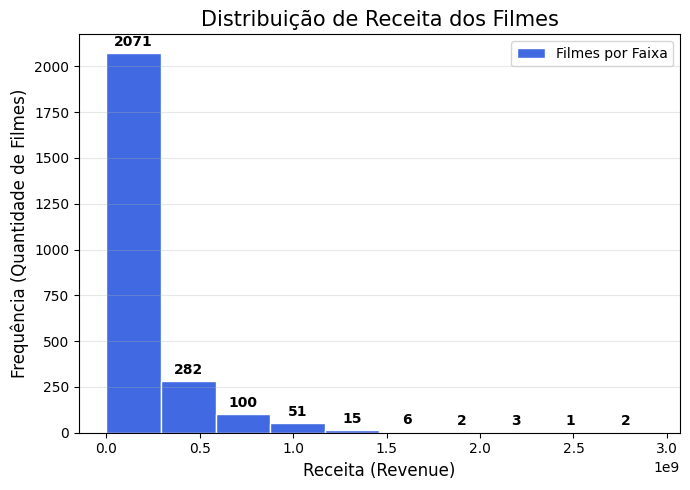

In [21]:
plt.figure(figsize=(7, 5))

# 2. Configuração do gráfico
# 'label' para a legenda e guardamos o retorno em 'bars'
counts, bins, bars = plt.hist(df_filtered['revenue'], bins=10,
                              color='royalblue', edgecolor='white',
                              label='Filmes por Faixa')

# Função bar_label pra trazer rótulo de dados nas barras
ax = plt.gca()
ax.bar_label(bars, padding=3, fontsize=10, fontweight='bold', color='black')

# 3. Legenda, Labels e Títulos
plt.title('Distribuição de Receita dos Filmes', fontsize=15)
plt.xlabel('Receita (Revenue)', fontsize=12)
plt.ylabel('Frequência (Quantidade de Filmes)', fontsize=12)

# O comando que faz a legenda aparecer:
plt.legend(loc='upper right', frameon=True)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

O histograma de faturamento mostra uma distribuição altamente assimétrica à direita, indicando que a maioria dos filmes possui baixo faturamento, enquanto poucos filmes concentram receitas extremamente altas.

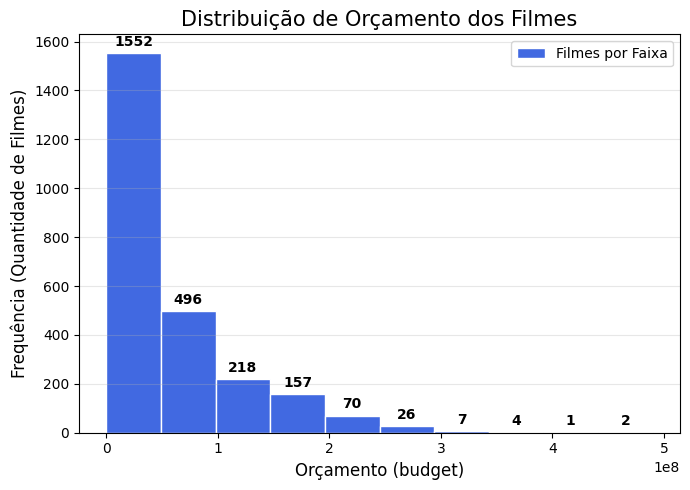

In [22]:
plt.figure(figsize=(7, 5))

# 2. Configuração do gráfico
# 'label' para a legenda e guardamos o retorno em 'bars'
counts, bins, bars = plt.hist(df_filtered['budget'], bins=10,
                              color='royalblue', edgecolor='white',
                              label='Filmes por Faixa')

# Função bar_label pra trazer rótulo de dados nas barras
ax = plt.gca()
ax.bar_label(bars, padding=3, fontsize=10, fontweight='bold', color='black')

# 3. Legenda, Labels e Títulos
plt.title('Distribuição de Orçamento dos Filmes', fontsize=15)
plt.xlabel('Orçamento (budget)', fontsize=12)
plt.ylabel('Frequência (Quantidade de Filmes)', fontsize=12)

# O comando que faz a legenda aparecer:
plt.legend(loc='upper right', frameon=True)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Assim como visto no faturamento, o histograma de orçamento também mostra uma distribuição assimétrica para a direita, demonstrando que grande parte dos filmes possui baixo orçamento.

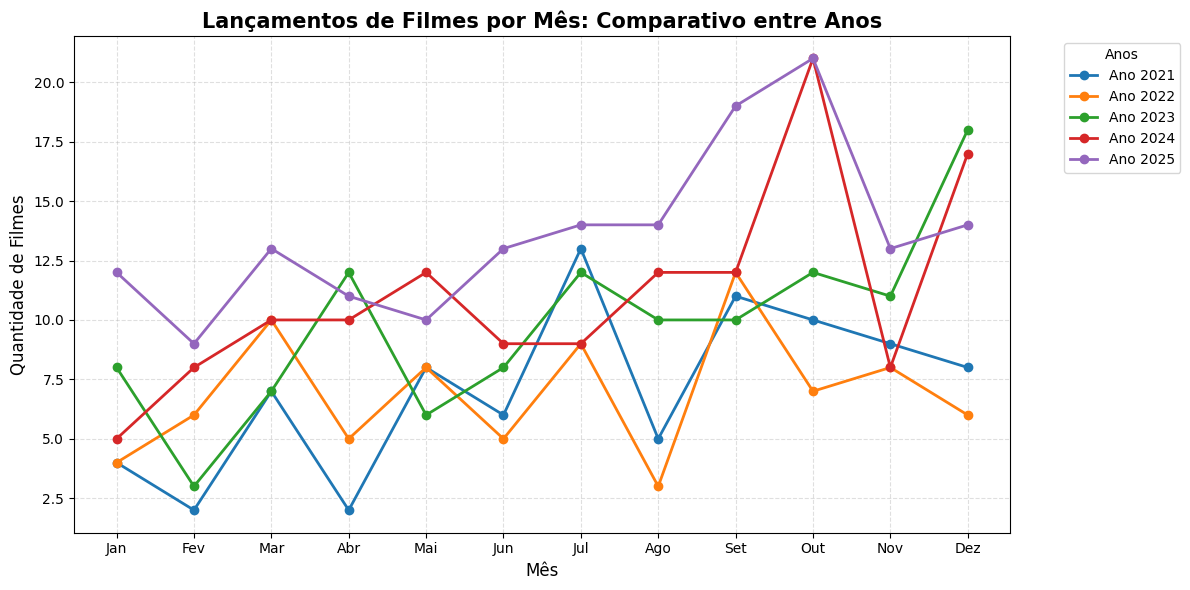

In [23]:
# 2. Filtrar apenas os anos recentes (ex: últimos 5 anos) para o gráfico não poluir
anos_recentes = sorted(df_filtered['year'].unique())[-5:]
df_plot = df_filtered[df_filtered['year'].isin(anos_recentes)]

# 3. Agrupar por Ano e Mês e contar
df_grouped = df_plot.groupby(['year', 'month', 'month_name']).size().reset_index(name='movie_count')

# 5. Configuração do Gráfico
plt.figure(figsize=(12, 6))

# Criamos uma linha para cada ano dentro de um loop
for ano in anos_recentes:
    dados_ano = df_grouped[df_grouped['year'] == ano]
    # Garantir a ordem dos meses de 1 a 12 na plotagem
    dados_ano = dados_ano.sort_values('month')

    plt.plot(dados_ano['month_name'], dados_ano['movie_count'],
             marker='o', label=f'Ano {int(ano)}', linewidth=2)

# 6. Estética e Labels
plt.title('Lançamentos de Filmes por Mês: Comparativo entre Anos', fontsize=15, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Quantidade de Filmes', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title="Anos", bbox_to_anchor=(1.05, 1), loc='upper left') # Legenda fora do gráfico

plt.tight_layout()
plt.show()

Observando o total de lançamentos por ano, notamos que a produção de filmes tem aumentado consideravelmente entre 2021 e 2025, sendo o último ano o de maior produção de filmes. Também conseguimos notar uma forte tendência de lançamentos de filmes no segundo semestre.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

### Tabela original

In [73]:
# estatísticas descritivas básicas do dataset
df_movies[['budget', 'revenue']].describe().style.format("{:.2f}")

,budget,revenue
count,9770.00,9770.00
mean,17366748.22,55993688.57
std,40414948.71,163461549.77
min,0.00,0.00
25%,0.00,0.00
50%,0.00,0.00
75%,14000000.00,24828096.50
max,489900000.00,2923706026.00


### Tabela analisada

In [74]:
df_filtered[['budget', 'revenue', 'profit']].describe().style.format("{:.2f}")

,budget,revenue,profit
count,2533.00,2533.00,2533.00
mean,55437599.69,177434726.32,121997126.63
std,60258784.23,268263316.17,229538202.32
min,1.00,1.00,-206000000.00
25%,13000000.00,19334145.00,688650.00
50%,34000000.00,83761844.00,45200000.00
75%,75000000.00,213978518.00,143959438.00
max,489900000.00,2923706026.00,2686706026.00


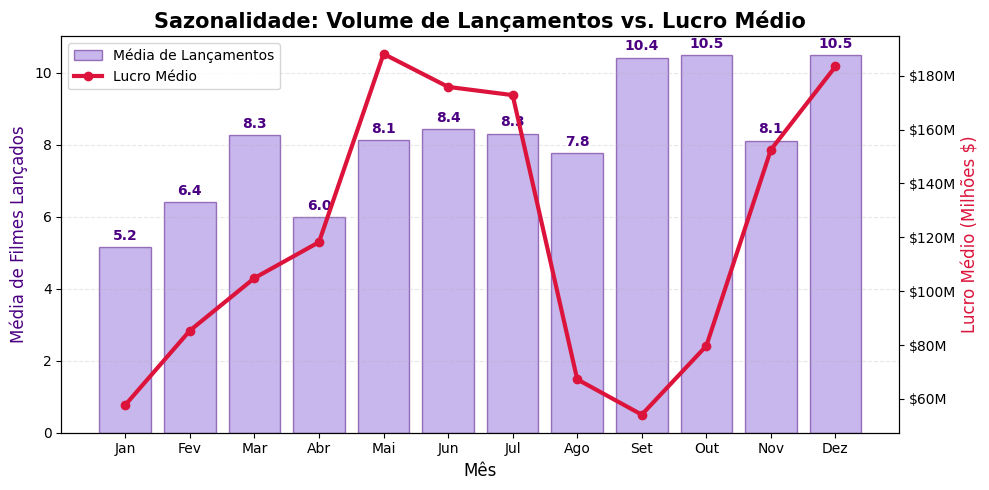

In [26]:
# 2. Agrupamento 1: Contagem de filmes e Lucro total por Ano/Mês
df_counts = df_filtered.groupby(['year', 'month']).agg({
    'release_date': 'size', # Conta filmes
    'profit': 'mean'        # Média de lucro naquele mês específico
}).rename(columns={'release_date': 'movie_count'}).reset_index()

# 3. Agrupamento 2: Média das médias por mês (Sazonalidade histórica)
df_monthly_avg = df_counts.groupby('month').agg({
    'movie_count': 'mean',
    'profit': 'mean'
}).reset_index()

# 5. Criar o gráfico
fig, ax1 = plt.subplots(figsize=(10, 5))

# --- BARRAS (Quantidade de Filmes) ---
bars = ax1.bar(df_monthly_avg['month'], df_monthly_avg['movie_count'],
               color='mediumpurple', edgecolor='indigo', alpha=0.5, label='Média de Lançamentos')
ax1.bar_label(bars, fmt='%.1f', padding=3, fontweight='bold', color='indigo')

# --- LINHA (Lucro Médio) ---
ax2 = ax1.twinx() # Cria o segundo eixo Y
ax2.plot(df_monthly_avg['month'], df_monthly_avg['profit'],
         color='crimson', marker='o', linewidth=3, label='Lucro Médio')

# 6. Formatação e Estética
def millions(x, pos):
    return f'${x / 1e6:.0f}M'

ax2.yaxis.set_major_formatter(FuncFormatter(millions))

meses_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
plt.xticks(range(1, 13), meses_labels)

ax1.set_xlabel('Mês', fontsize=12)
ax1.set_ylabel('Média de Filmes Lançados', color='indigo', fontsize=12)
ax2.set_ylabel('Lucro Médio (Milhões $)', color='crimson', fontsize=12)

plt.title('Sazonalidade: Volume de Lançamentos vs. Lucro Médio', fontsize=15, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Unindo as legendas
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

O gráfico de linhas mostra uma discrepância na sazonalidade dos filmes, com mais lançamentos realizados no segundo semestre, especialmente setembro e outubro, comparado com os dois maiores vales (fevereiro e abril), que estão no primeiro semestre. Entretanto, mesmo eles possuindo a maior média de lançamentos, também apresentam as piores performances de lucro médio no gráfico de linhas. Isso indica que há muita concorrência, mas com filmes de menor impacto comercial ou menor apelo de público. Junho não tem o maior volume de lançamentos (8.9, o que é mediano), mas possui o pico isolado de lucro médio (acima de $50M). Isso sugere que, em Junho, a estratégia é "qualidade sobre quantidade": lança-se menos filmes, porém são os blockbusters (grandes sucessos) que dominam o mercado.

/tmp/ipykernel_1850/760592417.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=df_filtered, x='month', y='profit',


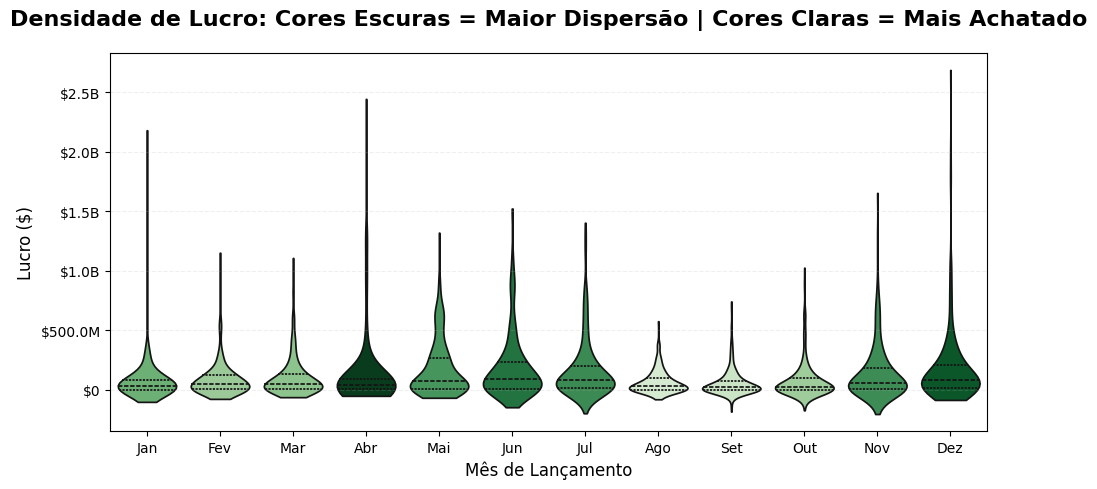

In [27]:
# 1. Calcular a métrica de "espalhamento" (Desvio Padrão) por mês
# Meses com menor desvio padrão são os mais "achatados" no zero
stats_por_mes = df_filtered.groupby('month')['profit'].std().reset_index()
stats_por_mes.columns = ['month', 'std_profit']

# 2. Criar um ranking para as cores (Normalizar entre 0 e 1)
# Quanto maior o desvio (mais espalhado), mais escuro o verde
stats_por_mes['color_intensity'] = (stats_por_mes['std_profit'] - stats_por_mes['std_profit'].min()) / \
                                   (stats_por_mes['std_profit'].max() - stats_por_mes['std_profit'].min())

# 3. Gerar a lista de cores baseada na intensidade
# Usamos um colormap (ex: "Greens") para extrair as cores
cmap = plt.get_cmap("Greens")
cores_mapeadas = [cmap(0.2 + 0.8 * val) for val in stats_por_mes['color_intensity']]

# --- CONFIGURAÇÃO DO GRÁFICO ---
plt.figure(figsize=(10, 5))

# Criamos o violinplot passando a lista de cores customizada
# O parâmetro 'palette' aceita a nossa lista de cores calculada
ax = sns.violinplot(data=df_filtered, x='month', y='profit',
                    palette=cores_mapeadas, inner="quartile", cut=0)

# Formatação do Eixo Y
def millions_billions_formatter(x, pos):
    if abs(x) >= 1e9: return f'${x / 1e9:.1f}B'
    if abs(x) >= 1e6: return f'${x / 1e6:.1f}M'
    if abs(x) >= 1e3: return f'${x / 1e3:.0f}K'
    return f'${x:.0f}'

plt.gca().yaxis.set_major_formatter(FuncFormatter(millions_billions_formatter))

# Nomes dos meses
meses_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
plt.xticks(range(0, 12), meses_labels)

plt.title('Densidade de Lucro: Cores Escuras = Maior Dispersão | Cores Claras = Mais Achatado',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Lucro ($)', fontsize=12)
plt.xlabel('Mês de Lançamento', fontsize=12)
plt.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

No gráfico de violino, Agosto e Setembro estão com as cores mais claras (verde pálido), significando que quase todos os filmes lançados nesses meses performam de forma ruim, amontoados em torno do zero ou com lucros baixos. Não há "explosões" de sucesso. Também observamos como Dezembro é verde escuro e o "pescoço" do violino é muito longo para cima. Dezembro é inconsistente (tem muitos fracassos e muitos sucessos gigantes), mas é onde os picos absolutos do ano se concentram. Enquanto isso, como observamos no gráfico anterior, os meses de maio e junho (verão do hemisfério norte), demonstram maior consistência na obtenção de lucros altos.

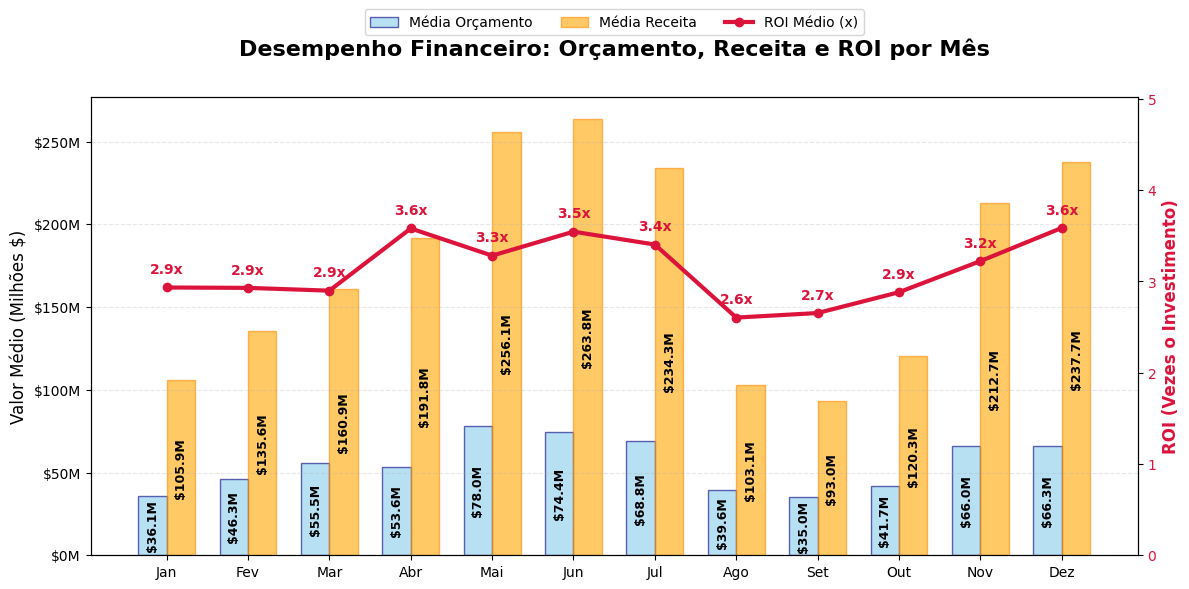

In [28]:
# --- 1. Preparação dos dados ---
# Agrupando e garantindo que todos os 12 meses existam
df_month_avg = df_filtered.groupby('month')[['budget', 'revenue']].mean().reset_index()
df_month_avg = df_month_avg.sort_values('month')

# Cálculo do ROI Médio por mês
df_month_avg['roi'] = df_month_avg['revenue'] / df_month_avg['budget']

# --- 2. CONFIGURAÇÃO DO GRÁFICO ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# DEFINIÇÃO DAS VARIÁVEIS FALTANTES
meses_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
x = np.arange(len(meses_labels)) # Define as posições 0 a 11
largura_barra = 0.35

# --- BARRAS (Eixo Y Esquerdo - Dinheiro) ---
bars_budget = ax1.bar(x - largura_barra/2, df_month_avg['budget'], largura_barra,
                      label='Média Orçamento', color='skyblue', edgecolor='navy', alpha=0.6)

bars_revenue = ax1.bar(x + largura_barra/2, df_month_avg['revenue'], largura_barra,
                       label='Média Receita', color='orange', edgecolor='darkorange', alpha=0.6)

# --- LINHA DE ROI (Eixo Y Direito - Multiplicador) ---
ax2 = ax1.twinx()
# O label aqui precisa ser uma lista para o legend() funcionar depois
line_roi = ax2.plot(x, df_month_avg['roi'], color='crimson', marker='o',
                    linewidth=3, label='ROI Médio (x)')

# Adicionando rótulos de texto na linha de ROI
for i, val in enumerate(df_month_avg['roi']):
    ax2.annotate(f'{val:.1f}x', (x[i], df_month_avg['roi'].iloc[i]),
                 textcoords="offset points", xytext=(0,10), ha='center',
                 color='crimson', fontweight='bold')

# --- 3. FORMATAÇÃO ---
def millions(x, pos):
    return f'${x / 1e6:.0f}M'

ax1.yaxis.set_major_formatter(FuncFormatter(millions))
ax2.set_ylabel('ROI (Vezes o Investimento)', color='crimson', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(0, df_month_avg['roi'].max() * 1.4) # Espaço para rótulos

# Função para adicionar rótulos nas barras (Melhorada para legibilidade)
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height/2,
                 f'${height/1e6:.1f}M',
                 ha='center', va='center', rotation=90,
                 color='black', fontweight='bold', fontsize=9)

add_labels(bars_budget)
add_labels(bars_revenue)

# --- 4. Títulos e Legendas ---
ax1.set_title('Desempenho Financeiro: Orçamento, Receita e ROI por Mês', fontsize=16, fontweight='bold', pad=30)
ax1.set_ylabel('Valor Médio (Milhões $)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(meses_labels)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Unindo as legendas de eixos diferentes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower center',
           bbox_to_anchor=(0.5, 1.12), ncol=3, frameon=True)

plt.tight_layout()
plt.show()

Com esse gráfico, observamos que o mercado cinematográfico opera em dois ciclos: o ciclo de escala (Maio/Junho), onde o faturamento é maximizado pelo alto investimento, e o ciclo de eficiência (Abril/Dezembro), onde o retorno sobre o capital é otimizado. Fora desses eixos, como visto em Agosto e Setembro, a redução drástica de custos não se traduz em segurança, mas sim em uma queda acentuada na capacidade de geração de receita. Com os menores investimentos médios do ano, a receita despenca proporcionalmente, resultando no menor ROI do dataset (2.6x - 2.7x). Isso prova que o baixo investimento inicial nestes meses atua como um teto de vidro: sem o "combustível" do orçamento de produção e marketing, os filmes não conseguem gerar a tração necessária para romper a barreira da estagnação comercial. O faturamento médio flutua mais de 180% entre o pior mês (Setembro) e o melhor (Junho), validando a hipótese de que o mês de lançamento é crucial.

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

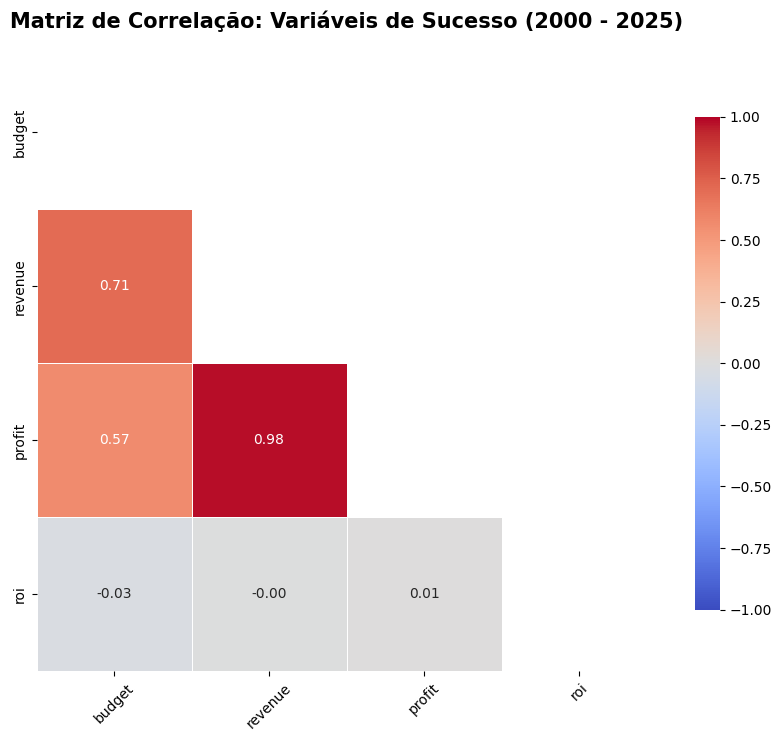

In [29]:
# Selecionando apenas as colunas de interesse para a correlação
cols = ['budget', 'revenue', 'profit', 'roi']
corr_matrix = df_filtered[cols].corr()

# 2. CONFIGURAÇÃO DO HEATMAP
plt.figure(figsize=(10, 8))

# Criando uma máscara para esconder a metade superior (opcional, para limpeza visual)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,          # Mostra os números dentro dos quadrados
            fmt=".2f",           # Duas casas decimais
            cmap='coolwarm',     # Azul (negativo) para Vermelho (positivo)
            vmin=-1, vmax=1,     # Escala fixa de correlação
            center=0,
            linewidths=.5,
            cbar_kws={"shrink": .8})

plt.title('Matriz de Correlação: Variáveis de Sucesso (2000 - 2025)', fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45)
plt.show()

Observamos uma correlação muito alta entre lucro e receita, porém isso acontece por uma questão de escala de grandeza. Como $Lucro = Receita - Orçamento$, e no cinema a Receita varia de forma muito mais agressiva (de poucos milhares a bilhões) do que o Orçamento (que raramente passa dos $300M), a receita acaba "mandando" no resultado final. Em contrapartida, o ROI tem resultado praticamente neutro, provando que o sucesso em termos de "retorno sobre cada dólar investido" é distribuído aleatoriamente. Existem filmes baratos muito eficientes e blockbusters caros muito eficientes (e vice-versa). Isso simboliza que gastar mais dinheiro (Budget) não necessariamente garante um retorno percentual melhor.

Top 5 zonas de maior densidade (maiores bolhas):
Faixa: Budget ~$0M | Revenue ~$0M -> 257 filmes
Faixa: Budget ~$10M | Revenue ~$0M -> 200 filmes
Faixa: Budget ~$20M | Revenue ~$0M -> 132 filmes
Faixa: Budget ~$20M | Revenue ~$50M -> 123 filmes
Faixa: Budget ~$10M | Revenue ~$50M -> 93 filmes


/tmp/ipykernel_1850/2919238834.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


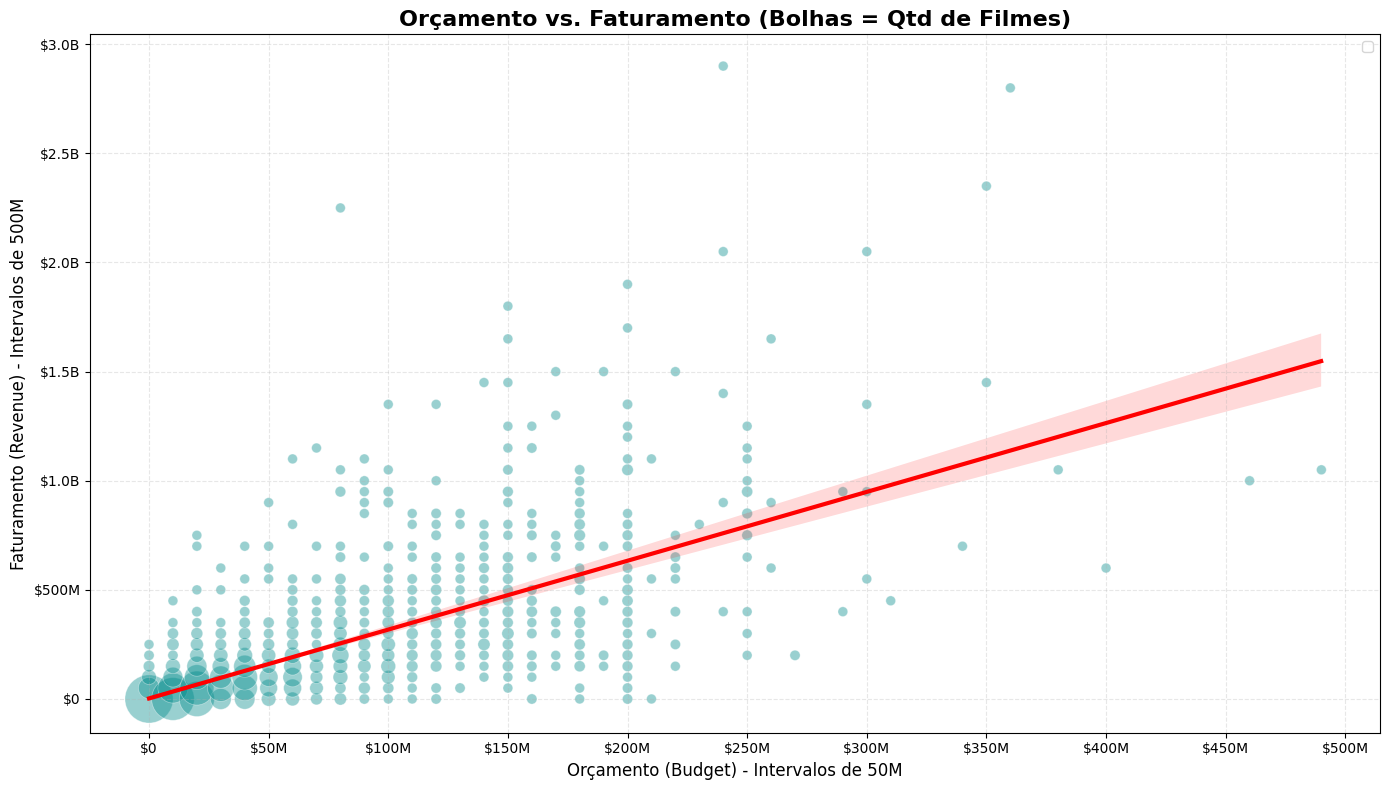

In [33]:
# 1. Agrupamento para definir o tamanho das bolinhas (Bubble Chart)
df_bubbles = df_filtered.copy()
# Criando faixas para agrupar filmes com valores próximos
df_bubbles['budget_bin'] = (df_bubbles['budget'] / 1e7).round() * 1e7 # Tamanho do Bin de Orçamento: $10M
df_bubbles['revenue_bin'] = (df_bubbles['revenue'] / 5e7).round() * 5e7 # Tamanho do Bin de Faturamento: $50M

df_counts_for_bubble = df_bubbles.groupby(['budget_bin', 'revenue_bin']).size().reset_index(name='movie_count')

top_bins = df_counts_for_bubble.sort_values('movie_count', ascending=False).head(5)
print("Top 5 zonas de maior densidade (maiores bolhas):")
for i, row in top_bins.iterrows():
    print(f"Faixa: Budget ~${row['budget_bin']/1e6:.0f}M | Revenue ~${row['revenue_bin']/1e6:.0f}M -> {int(row['movie_count'])} filmes")

# 2. Configuração do Gráfico
plt.figure(figsize=(14, 8))

# Scatter com tamanho proporcional à contagem
sns.scatterplot(data=df_counts_for_bubble, x='budget_bin', y='revenue_bin',
                size='movie_count', sizes=(50, 1200), alpha=0.4,
                color='darkcyan', edgecolor='white', legend=None)

# Linha de tendência (sem desenhar os pontos originais para não sobrepor)
sns.regplot(data=df_filtered, x='budget', y='revenue',
            scatter=False, color='red', line_kws={'linewidth': 3, 'label': 'Tendência Linear'})

# --- AJUSTE DAS ESCALAS (Ticks) ---
# Eixo Y a cada 500M
plt.gca().yaxis.set_major_locator(MultipleLocator(500000000))
# Eixo X a cada 50M
plt.gca().xaxis.set_major_locator(MultipleLocator(50000000))

# 3. Formatação dos Eixos (Legível em M e B)
def millions_billions(x, pos):
    if abs(x) >= 1e9: return f'${x/1e9:.1f}B'
    if abs(x) >= 1e6: return f'${x/1e6:.0f}M'
    return f'${x:.0f}'

plt.gca().yaxis.set_major_formatter(FuncFormatter(millions_billions))
plt.gca().xaxis.set_major_formatter(FuncFormatter(millions_billions))

# 4. Títulos e Estética
plt.title('Orçamento vs. Faturamento (Bolhas = Qtd de Filmes)', fontsize=16, fontweight='bold')
plt.xlabel('Orçamento (Budget) - Intervalos de 50M', fontsize=12)
plt.ylabel('Faturamento (Revenue) - Intervalos de 500M', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Como observamos nesse gráfico e no gráfico de desempenho financeiro por mês, a grande maioria dos filmes com orçamento próximo de \$0 até \$100M está "presa" na base do gráfico, raramente ultrapassando a marca dos $500M de faturamento. O Bubble Plot mostra que, sem investimento, as chances de um filme "furar a bolha" e chegar aos bilhões são estatisticamente irrelevantes. Não existe nenhum ponto no gráfico que tenha Budget até \$50M e Revenue > \$1B

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

A hipótese escolhida para o desenvolvimento do modelo de machine learning foi a relação entre orçamento e faturamento dos filmes. Essa escolha se justifica pelo fato de que o faturamento (revenue) é uma variável contínua diretamente associada ao desempenho financeiro das produções, sendo um dos principais indicadores de sucesso na indústria cinematográfica.

Além disso, a análise exploratória indicou a existência de uma relação positiva entre orçamento e faturamento, ainda que com variabilidade, sugerindo que o orçamento pode atuar como um preditor relevante. Diferentemente do ROI, que apresentou comportamento mais aleatório, o faturamento mostrou padrões mais consistentes, tornando-o mais adequado como variável alvo em um modelo supervisionado.

Dessa forma, o problema pode ser formulado como uma tarefa de regressão supervisionada, na qual o objetivo é prever o faturamento de um filme com base em suas características, como orçamento e data de lançamento.

In [66]:
# Separar features (X) e target (y)
X = df_filtered[['budget', 'month']]
y = np.log1p(df_filtered['revenue'])

Foi aplicada a transformação logarítmica na variável de faturamento utilizando np.log1p, com o objetivo de reduzir a assimetria da distribuição e o impacto de valores extremos. Como observado na análise exploratória, o faturamento apresenta uma distribuição altamente enviesada à direita, com poucos filmes concentrando receitas muito elevadas. A aplicação do log torna a distribuição mais próxima de uma normal, facilitando o aprendizado do modelo e melhorando sua capacidade de generalização.

In [67]:
X = pd.get_dummies(X, columns=['month'], drop_first=True)

A variável de mês de lançamento foi transformada utilizando one-hot encoding por meio da função get_dummies. Essa abordagem converte a variável categórica em um conjunto de variáveis binárias, permitindo que o modelo trate cada mês de forma independente, sem assumir uma relação ordinal entre eles. O parâmetro `drop_first=True` foi utilizado para evitar multicolinearidade, removendo uma das categorias de referência e garantindo estabilidade no modelo de regressão. Sem essa configuração, as variáveis dummy seriam linearmente dependentes, já que a soma de todas elas é sempre igual a 1. Ao remover uma das categorias, estabelece-se uma categoria de referência (baseline), permitindo que o modelo interprete os coeficientes das demais variáveis como variações em relação a essa base, garantindo maior estabilidade e interpretabilidade dos resultados.

In [68]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [69]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (1773, 12)
Dimensões de X_test: (760, 12)
Dimensões de y_train: (1773,)
Dimensões de y_test: (760,)


## Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais.

In [62]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

In [70]:
X_train['budget'] = scaler_std.fit_transform(X_train[['budget']])
X_test['budget'] = scaler_std.transform(X_test[['budget']])

In [64]:
# Exibir as primeiras linhas dos dados padronizados (como DataFrame para melhor visualização)
df_standardized = pd.DataFrame(X_train, columns=X_train.columns)

A padronização foi aplicada apenas à variável de orçamento utilizando o StandardScaler, uma vez que essa variável apresenta valores em escala muito superior às demais. O processo transforma os dados para que tenham média zero e desvio padrão unitário, evitando que o modelo atribua peso excessivo a variáveis com maior magnitude. As variáveis binárias resultantes do one-hot encoding não foram padronizadas, pois já se encontram em uma escala adequada (0 e 1) e sua transformação poderia prejudicar a interpretabilidade do modelo.

In [65]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())


Primeiras 5 linhas dos dados padronizados (treino):
        budget  month_2  month_3  month_4  month_5  month_6  month_7  month_8  \
330   1.770099    False    False    False     True    False    False    False   
233   0.262281    False    False    False    False    False    False    False   
3745 -0.349347    False    False    False    False    False    False    False   
462  -0.156557    False    False    False    False    False    False    False   
6869  2.524008    False    False    False    False    False    False     True   

      month_9  month_10  month_11  month_12  
330     False     False     False     False  
233     False     False     False      True  
3745     True     False     False     False  
462      True     False     False     False  
6869    False     False     False     False  


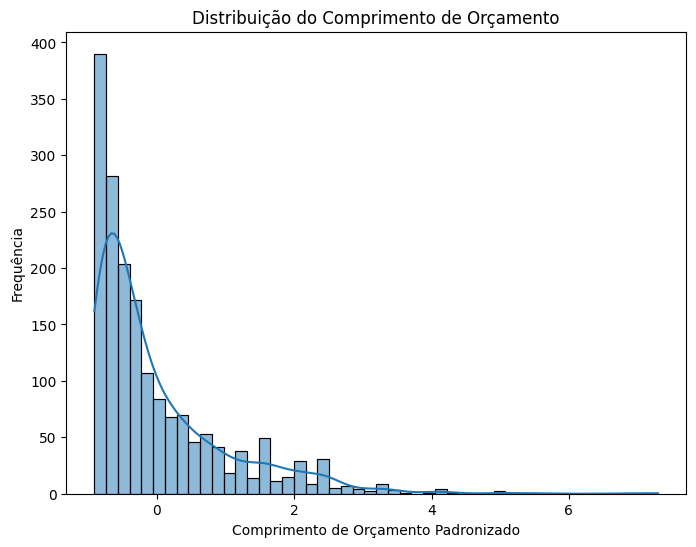

In [72]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['budget'], kde=True)
plt.title('Distribuição do Comprimento de Orçamento')
plt.xlabel('Comprimento de Orçamento Padronizado')
plt.ylabel('Frequência')
plt.show()

O histograma da variável de orçamento após a padronização mostra que os dados foram centralizados em torno de zero, com desvio padrão unitário. No entanto, observa-se que a assimetria da distribuição foi preservada, indicando que a padronização não altera o formato dos dados, mas apenas sua escala. A presença de valores extremos ainda é perceptível, o que reforça que a variável possui alta variabilidade mesmo após o pré-processamento.

# Conclusão

A análise e o pré-processamento do dataset movies reforça que o sucesso financeiro na indústria é fruto de uma complexa relação entre investimento e sazonalidade. O dataset apresenta uma correlação de Pearson de 0.71 entre orçamento e faturamento, indicando que, embora o capital seja um preditor forte, a variabilidade extrema (outliers de bilhões) exige cautela. A análise exploratória revelou "janelas de eficiência" críticas, onde meses como Dezembro e Abril entregam os maiores ROIs médios (3.6x), enquanto períodos de baixo investimento, como Setembro, resultam em estagnação comercial.

No que se refere ao pré-processamento dos dados, foram aplicadas técnicas adequadas para preparar as variáveis para a modelagem. A variável categórica de mês de lançamento foi transformada por meio de one-hot encoding, permitindo que o modelo interpretasse cada mês de forma independente, sem assumir relações ordinais entre eles. A variável de orçamento, por apresentar grande variação de escala, foi padronizada utilizando o StandardScaler, garantindo média zero e desvio padrão unitário, de forma a evitar que sua magnitude influenciasse desproporcionalmente o modelo. Já a variável alvo (faturamento) foi transformada por meio de uma função logarítmica (log1p), com o objetivo de reduzir a assimetria da distribuição e o impacto de valores extremos, melhorando a capacidade de generalização do modelo.

As três hipóteses levantadas foram analisadas e validadas a partir da análise exploratória dos dados:

1. **Filmes com maior orçamento tendem a apresentar maior faturamento?**
Sim, os gráficos de dispersão e as análises realizadas indicam uma relação positiva entre orçamento e faturamento. Filmes com maior investimento tendem a alcançar receitas mais elevadas, embora essa relação não seja determinística, já que existem exceções em diferentes faixas de orçamento.

2. **O mês de lançamento de um filme influencia seu faturamento?**
Sim, foi possível identificar padrões sazonais claros no desempenho financeiro dos filmes. Alguns meses apresentam maior consistência em altos faturamentos, enquanto outros concentram produções com baixo desempenho, evidenciando estratégias distintas de lançamento ao longo do ano.

3. **Filmes com maior orçamento apresentam maior retorno sobre investimento (ROI)?**
Não, a análise mostrou que não há uma relação direta entre orçamento e eficiência financeira. Filmes com diferentes níveis de investimento apresentam retornos variados, indicando que gastar mais não garante um melhor retorno percentual.